Calculating geometric intersections...


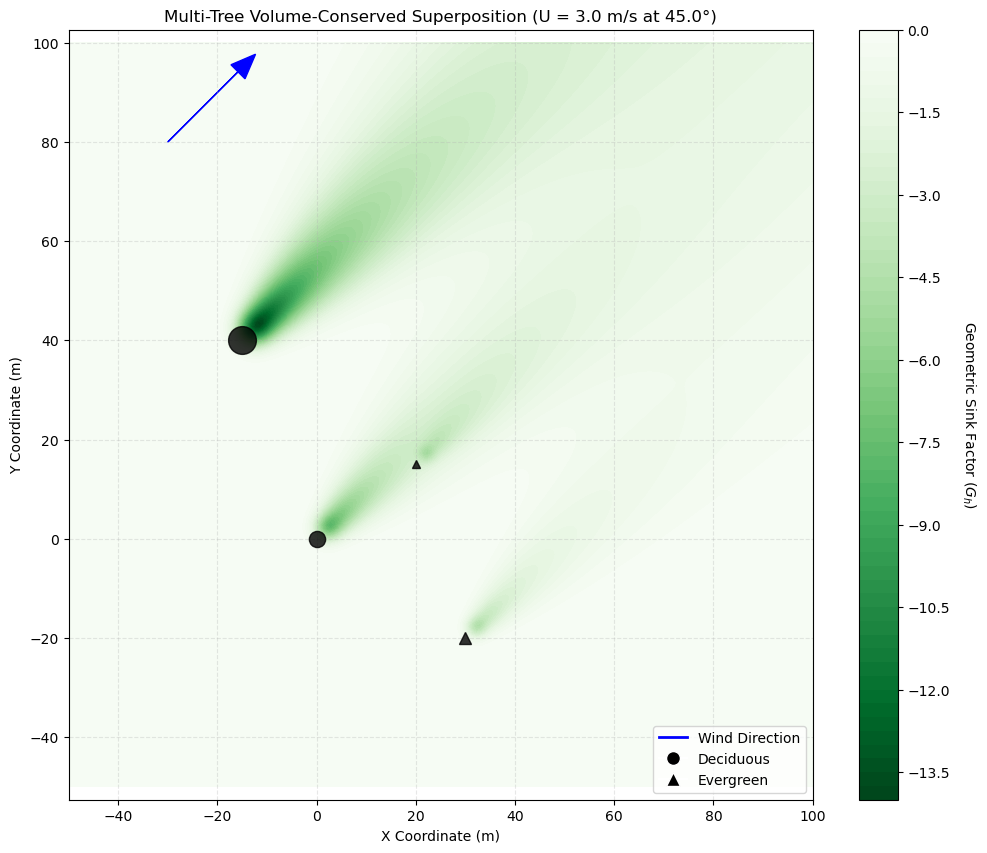

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Core Mathematical Functions
# ==========================================

def calculate_tree_volume(base_area, height, tree_type):
    """Calculates crown volume based on precise tree geometry."""
    if tree_type.lower() == 'deciduous':
        return base_area * height * (2/3)  # Ellipsoidal
    elif tree_type.lower() == 'evergreen':
        return base_area * height * (1/3)  # Conical
    else:
        raise ValueError("tree_type must be 'deciduous' or 'evergreen'")

def calculate_sigma_0(volume):
    """Converts a tree's crown volume (m^3) to the initial Gaussian dispersion parameter."""
    radius = (3 * volume / (4 * np.pi))**(1/3)
    return radius / 2.15

def calculate_spatial_geometric_sink(X, Y, trees, U, wind_dir_deg, T_max=600, D=0.5):
    """
    Calculates the Geometric Sink Factor (G) across an entire 2D spatial grid,
    enforcing Strict Conservation of Absorption scaled by tree volume.
    """
    theta = np.radians(wind_dir_deg)
    u_wind = U * np.cos(theta)
    v_wind = U * np.sin(theta)
    
    t_array = np.arange(1, T_max + 1)
    
    # Add a 3rd dimension to our 2D grid for fast 3D broadcasting (X, Y, Time)
    X_3d = X[..., np.newaxis]
    Y_3d = Y[..., np.newaxis]
    
    G_total_grid = np.zeros_like(X, dtype=float)
    
    for tree in trees:
        tx = tree['x']
        ty = tree['y']
        
        # --- THE NEW VOLUME LOGIC ---
        # 1. Calculate precise volume based on type
        vol = calculate_tree_volume(tree['A'], tree['H'], tree['type'])
        
        # 2. Calculate the initial spread (sigma_0)
        sigma_0 = calculate_sigma_0(vol)
        
        # Calculate puff locations and sizes over time
        puff_x = tx + (u_wind * t_array)
        puff_y = ty + (v_wind * t_array)
        sigma_t = sigma_0 + (D * t_array)
        
        # Calculate squared distance from EVERY grid point to EVERY puff simultaneously
        dist_sq = (X_3d - puff_x)**2 + (Y_3d - puff_y)**2
        
        # --- THE CONSERVATION OF ABSORPTION ---
        # Multiply the normalized Gaussian PDF directly by the calculated volume.
        coeff = vol / (2 * np.pi * sigma_t**2)
        exponent = np.exp(-dist_sq / (2 * sigma_t**2))
        
        # Sum along the time axis to flatten the puffs down into a single 2D layer
        puffs_contrib = coeff * exponent 
        tree_grid = np.sum(puffs_contrib, axis=2)
        
        # Superimpose this tree's field onto the master map
        G_total_grid += tree_grid
        
    return G_total_grid

# ==========================================
# 2. Visualization Setup
# ==========================================

# Create the spatial grid
x_coords = np.linspace(-50, 100, 200)
y_coords = np.linspace(-50, 100, 200)
X, Y = np.meshgrid(x_coords, y_coords)

# Define the local forest using Base Area (A), Height (H), and Type
local_trees = [
    {'x': 0.0,   'y': 0.0,   'A': 20.0, 'H': 10.0, 'type': 'deciduous'},  # Center tree
    {'x': 20.0,  'y': 15.0,  'A': 10.0, 'H': 8.0,  'type': 'evergreen'},  # Smaller tree
    {'x': -15.0, 'y': 40.0,  'A': 30.0, 'H': 15.0, 'type': 'deciduous'},  # Massive tree
    {'x': 30.0,  'y': -20.0, 'A': 15.0, 'H': 12.0, 'type': 'evergreen'}   # Bottom right tree
]

# Define the specific hour's weather
WIND_SPEED = 3.0      # m/s
WIND_DIR = 45.0       # Blowing towards North-East
MAX_TIME = 600        # Integrate over 10 minutes of air
DIFFUSION = 0.5       # Plume spread rate

# ==========================================
# 3. Calculate and Plot
# ==========================================

print("Calculating geometric intersections...")
sink_map = calculate_spatial_geometric_sink(X, Y, local_trees, WIND_SPEED, WIND_DIR, MAX_TIME, DIFFUSION)

plt.figure(figsize=(12, 10))

# Plot the negative so it visualizes as a "sink" (depth)
contour = plt.contourf(X, Y, -sink_map, levels=60, cmap='Greens_r')
cbar = plt.colorbar(contour)
cbar.set_label('Geometric Sink Factor ($G_h$)', rotation=270, labelpad=20)

# Plot the trees 
for tree in local_trees:
    # Scale marker size slightly based on calculated volume for visual effect
    vol = calculate_tree_volume(tree['A'], tree['H'], tree['type'])
    marker_size = (vol / 20) + 5
    
    # Use different markers for evergreen vs deciduous
    marker_style = '^' if tree['type'] == 'evergreen' else 'o'
    plt.plot(tree['x'], tree['y'], marker=marker_style, color='black', markersize=marker_size, alpha=0.8)

# Draw Wind Arrow
arrow_length = 20
plt.arrow(-30, 80, 
          arrow_length * np.cos(np.radians(WIND_DIR)), 
          arrow_length * np.sin(np.radians(WIND_DIR)), 
          head_width=4, head_length=5, fc='blue', ec='blue', label='Wind Direction')

plt.title(f'Multi-Tree Volume-Conserved Superposition (U = {WIND_SPEED} m/s at {WIND_DIR}°)')
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')

# Add custom legend entries for the tree shapes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Wind Direction'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Deciduous'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=10, label='Evergreen')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.show()